Linear Regression — What it CAN and CANNOT do

What Linear Regression is USED for

Linear Regression predicts a continuous numeric value.

Can be used for 
    HOUSE PRICE

    SALRY

    TEMPERATURE

    Marks / score

    Sales amount

    
    Weight / height
    
    Medical measurement

Cannot be used for 

    YES/NO

    O/1

    PASS/FAIL

    Disease / No disease


I am going use the "Machine Learning Student Mark Prediction" FOR PREIDCTING  FOR Student MARK Prediction

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib as plt
print("done")

done


In [2]:
df=pd.read_csv(r"C:\Users\ADMIN\OneDrive\Desktop\ml-libraries-and-frame-work\student_info(2).csv")

In [3]:
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


In [4]:
df.shape

(200, 2)

In [5]:
df.columns

Index(['study_hours', 'student_marks'], dtype='object')

In [6]:
df.isnull().sum()


study_hours      5
student_marks    0
dtype: int64

In [7]:
df.dropna(inplace=True)


In [8]:
df.isnull().sum()


study_hours      0
student_marks    0
dtype: int64

In [9]:
df

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
3,5.67,71.82
4,8.67,84.19
5,7.55,81.18
...,...,...
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05


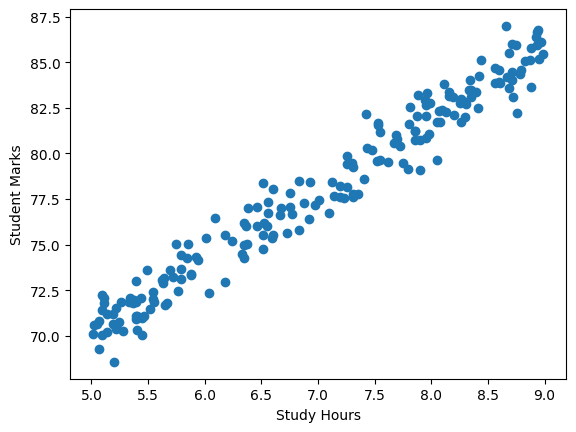

In [10]:
import matplotlib.pyplot as plt
plt.scatter(df['study_hours'], df['student_marks'])
plt.xlabel("Study Hours")
plt.ylabel("Student Marks")
plt.show()


In [11]:
X = df[['study_hours']]
y = df['student_marks']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [14]:
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
model.coef_
model.intercept_


np.float64(50.87256476190835)

In [16]:
y_pred=model.predict(X_test)

In [17]:
model.predict([[7.53]])

c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([79.99721448])

In [18]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 1.2516176668509067
R2 Score: 0.9491213668579527


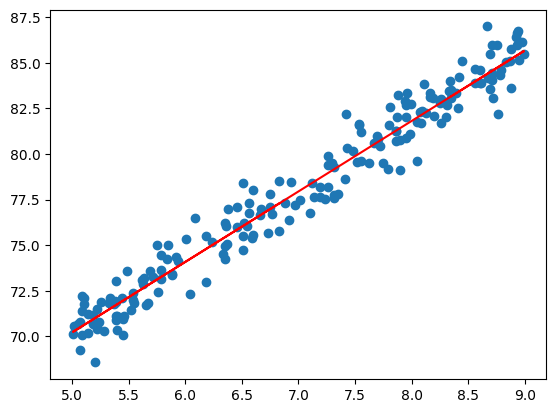

In [19]:
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.show()


In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
params = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20]}
ridge_regressor = GridSearchCV(
    ridge,
    params,
    scoring='neg_mean_squared_error',
    cv=5
)
ridge.fit(X,y)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [27]:
ridge_regressor.fit(X,y)
print(ridge_regressor.best_params_)
print(ridge_regressor.best_score_)


{'alpha': 1e-15}
-0.995195925875955


In [29]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso= Lasso()
params = {'alpha': [1e-15, 1e-10, 1e-8, 1e-3, 1e-2, 1, 5, 10, 20]}
lasso_regressor = GridSearchCV(
    lasso,
    params,
    scoring='neg_mean_squared_error',
    cv=5
)
lasso.fit(X,y)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [30]:
lasso_regressor.fit(X,y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)


{'alpha': 1e-15}
-0.9951959258759544


c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.086e+00, tolerance: 4.043e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.273e+01, tolerance: 3.866e-01
  model = cd_fast.enet_coordinate_descent(
c:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca